In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import scikit_posthocs as sp

In [4]:
df = pd.read_csv("../data/contractor_resolution_times.csv")

df.head()

,contractor_name,resolution_time_minutes
0,Contractor C,775.0
1,Contractor E,310.0
2,Contractor B,388.0
3,Contractor C,521.0
4,Contractor E,90.0


In [5]:
df.groupby("contractor_name")["resolution_time_minutes"].count()

contractor_name
Contractor A    103
Contractor B    104
Contractor C    105
Contractor D     99
Contractor E    104
Name: resolution_time_minutes, dtype: int64

In [6]:
df.groupby('contractor_name')['resolution_time_minutes'].describe()

,count,mean,std,min,25%,50%,75%,max
contractor_name,,,,,,,,
Contractor A,103.0,577.116505,259.194465,90.0,372.50,552.0,760.50,1214.0
Contractor B,104.0,399.923077,191.539278,72.0,240.00,388.0,532.75,898.0
Contractor C,105.0,744.371429,356.124310,96.0,456.00,763.0,977.00,1601.0
Contractor D,99.0,545.131313,248.646074,72.0,351.00,533.0,690.00,1193.0
Contractor E,104.0,559.250000,291.387966,81.0,348.25,506.0,745.75,1204.0


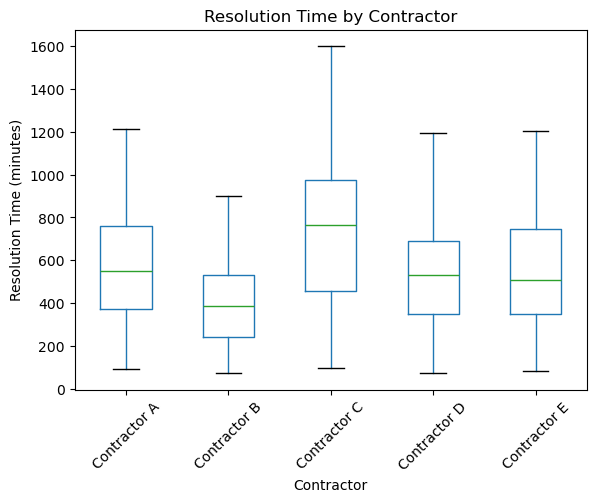

In [7]:
df.boxplot(column='resolution_time_minutes', by='contractor_name', grid=False, rot=45)


plt.title("Resolution Time by Contractor")
plt.suptitle("")
plt.xlabel("Contractor")
plt.ylabel("Resolution Time (minutes)")
plt.show()

## Kruskal–Wallis Test

The descriptive analysis showed differences in resolution times across contractors.

A Kruskal–Wallis test is used to determine whether these differences are statistically significant across the five contractor groups.

- **H0:** The resolution-time distributions are the same across contractors.
- **H1:** At least one contractor has a different resolution-time distribution.
- **Significance level:** α = 0.05

If the p-value is below 0.05, H0 is rejected.

In [8]:
groups = [
    group["resolution_time_minutes"].values
    for _, group in df.groupby("contractor_name")
]

h_statistic, p_value = stats.kruskal(*groups)

print("H-statistic:", h_statistic)
print("p-value:", p_value)

H-statistic: 63.228656807920125
p-value: 6.074073810142599e-13


### Kruskal–Wallis Result and Post-hoc Analysis

The Kruskal–Wallis test showed a statistically significant difference in resolution-time distributions across contractors (H = 63.23, p < 0.001). Therefore, the null hypothesis was rejected.

However, the Kruskal–Wallis test only shows that at least one contractor differs; it does not identify which contractor pairs are different.

Therefore, Dunn's post-hoc test is used for pairwise comparisons. Since multiple comparisons are performed, the Holm correction is applied to control the risk of false-positive results.

For each contractor pair:
- **H0:** The resolution-time distributions are the same.
- **H1:** The resolution-time distributions are different.
- **Significance level:** α = 0.05

In [9]:
dunn_results = sp.posthoc_dunn(
    df,
    val_col="resolution_time_minutes",
    group_col="contractor_name",
    p_adjust="holm"
)

dunn_results

,Contractor A,Contractor B,Contractor C,Contractor D,Contractor E
Contractor A,1.000000,2.152520e-05,6.669864e-03,1.000000,1.000000
Contractor B,0.000022,1.000000e+00,2.988525e-14,0.000617,0.000598
Contractor C,0.006670,2.988525e-14,1.000000e+00,0.000617,0.000617
Contractor D,1.000000,6.169506e-04,6.169506e-04,1.000000,1.000000
Contractor E,1.000000,5.976097e-04,6.169506e-04,1.000000,1.000000


### Post-hoc Results

Dunn's post-hoc test showed significant differences between several contractor pairs.

Significant differences were found for:
- A vs B
- A vs C
- B vs C
- B vs D
- B vs E
- C vs D
- C vs E

No statistically significant differences were found for:
- A vs D
- A vs E
- D vs E

The results indicate that Contractors B and C differ significantly from several other contractors. Descriptive statistics are used to understand the direction and magnitude of these differences.

## Final Conclusion

The analysis found clear differences in incident resolution times across contractors.

Contractor B had the lowest median resolution time (388 minutes), while Contractor C had the highest median resolution time (763 minutes). Contractors A, D and E showed intermediate median resolution times.

The Kruskal–Wallis test confirmed that the resolution-time distributions were not the same across all contractors (H = 63.23, p < 0.001).

Dunn's post-hoc test showed that Contractor B differed significantly from A, C, D and E. Contractor C also differed significantly from A, B, D and E. No statistically significant differences were found among Contractors A, D and E.

Overall, the results show that the observed differences for Contractors B and C are supported by statistical evidence. However, these results do not establish causation, and operational factors such as incident priority, location and complexity should also be considered when evaluating contractor performance.